In [1]:
# !pip install optuna

In [2]:
# Importing the libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [3]:
# Prepare your data

df = pd.read_csv('cancer-risk-factors.csv')

In [4]:
df.head(5)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


In [5]:
X = df.drop(columns=['Risk_Level','Patient_ID', 'Cancer_Type'])

# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(df['Risk_Level'])

In [6]:
X

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level
0,68,0,7,2,8,0,5,3,7,4,6,3,1,0,0,0.398696,28.0,5
1,74,1,8,9,8,0,0,3,7,1,3,3,0,0,5,0.424299,25.4,9
2,55,1,7,10,7,0,3,3,4,1,8,10,0,0,6,0.605082,28.6,2
3,61,0,6,2,2,0,6,2,4,6,4,8,0,0,8,0.318449,32.1,7
4,67,1,10,7,4,0,6,3,10,9,10,9,0,0,5,0.524358,25.1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,60,1,4,6,4,0,10,6,4,4,5,3,1,0,4,0.437539,30.3,3
1996,84,1,5,7,8,0,10,0,1,2,1,3,0,0,2,0.451128,25.9,4
1997,65,0,7,2,10,0,4,2,2,3,6,0,0,1,0,0.295760,22.5,3
1998,64,1,10,2,10,0,2,10,7,5,4,2,0,0,10,0.422201,25.3,3


In [7]:
y

array([2, 2, 2, ..., 1, 2, 2], shape=(2000,))

## why cancer_type was removed from the features list

- It's not a predictive input - it's an outcome label or categorical grouping that's already strongly correlated with Risk Level

- If we include it, the model will cheat by learning the mapping like Prostate --> High risk, instead of learning from true risk factors (smoking, BMI etc)

In [8]:
# Split into training/test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [9]:
# Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

        High       1.00      0.95      0.97        20
         Low       1.00      1.00      1.00        65
      Medium       1.00      1.00      1.00       315

    accuracy                           1.00       400
   macro avg       1.00      0.98      0.99       400
weighted avg       1.00      1.00      1.00       400

Confusion Matrix
[[ 19   0   1]
 [  0  65   0]
 [  0   0 315]]


The model accurately distinguishes all risk levels, with only 1 mistake out of 400 with imbalanced dataset.

## Logistic Regression

In [12]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
y_pred_lr = log_reg.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Classification Report
              precision    recall  f1-score   support

        High       1.00      0.80      0.89        20
         Low       0.97      0.95      0.96        65
      Medium       0.98      0.99      0.99       315

    accuracy                           0.98       400
   macro avg       0.98      0.92      0.95       400
weighted avg       0.98      0.98      0.98       400

Confusion Matrix
[[ 16   0   4]
 [  0  62   3]
 [  0   2 313]]


## Removing Overall_Risk_Score and retrying

In [14]:
X_new = df.drop(columns=['Risk_Level','Patient_ID', 'Cancer_Type', 'Overall_Risk_Score'])

# Encode the target variable
le_new = LabelEncoder()
y_new = le_new.fit_transform(df['Risk_Level'])

In [15]:
# Split into training/test

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size = 0.2, random_state=42, stratify=y)

In [16]:
# Feature Scaling

scaler_new = StandardScaler()
X_train_new = scaler_new.fit_transform(X_train_new)
X_test_new = scaler_new.transform(X_test_new)

In [17]:
model_new = RandomForestClassifier(random_state=42, n_estimators=100)
model_new.fit(X_train_new, y_train_new)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
y_pred_new = model_new.predict(X_test_new)

print("Classification Report")
print(classification_report(y_test_new, y_pred_new, target_names=le.classes_))

print("Confusion Matrix")
print(confusion_matrix(y_test_new, y_pred_new))

Classification Report
              precision    recall  f1-score   support

        High       1.00      0.05      0.10        20
         Low       0.85      0.34      0.48        65
      Medium       0.83      0.99      0.90       315

    accuracy                           0.83       400
   macro avg       0.89      0.46      0.49       400
weighted avg       0.84      0.83      0.80       400

Confusion Matrix
[[  1   0  19]
 [  0  22  43]
 [  0   4 311]]


In [19]:
df.Risk_Level.value_counts()

Risk_Level
Medium    1574
Low        324
High       102
Name: count, dtype: int64

## SMOTE - Synthetic Minority Over-Sampling Technique

In [20]:
X = df.drop(columns=['Risk_Level','Patient_ID', 'Cancer_Type', 'Overall_Risk_Score'])
y = df['Risk_Level']

In [21]:
# Split into training/test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

In [22]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train,y_train)

print("Class Distribution")
print(y_train_res.value_counts())

Class Distribution
Risk_Level
Medium    1259
Low       1259
High      1259
Name: count, dtype: int64


In [23]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_pred = rf_model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

        High       0.41      0.35      0.38        20
         Low       0.73      0.58      0.65        65
      Medium       0.88      0.92      0.90       315

    accuracy                           0.84       400
   macro avg       0.67      0.62      0.64       400
weighted avg       0.83      0.84      0.83       400

Confusion Matrix
[[  7   0  13]
 [  0  38  27]
 [ 10  14 291]]


- Accuracy: 84%
- High Risk: 7 correctly classified, 13 mis-classified as Medium
- Low Risk: 38 correctly classified, 27 confused with Medium
- Medium Risk: 291 correctly classified, 24 confused as High/Low

- Still struggles to detect High-risk patients even with SMOTE

## Optuna Tuning

In [25]:
# Optuna tuning
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

import numpy as np
import joblib  # optional, to save model/study

e:\miniconda3\envs\cancer1\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
X_train_res.shape

(3777, 17)

In [27]:
from sklearn.metrics import f1_score, make_scorer

# Define macro F1 scorer explicitly for multiclass
def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

scorer = make_scorer(macro_f1)


In [28]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train_res, y_train_res):
        X_t, X_v = X_train_res.iloc[train_idx], X_train_res.iloc[val_idx]
        y_t, y_v = y_train_res.iloc[train_idx], y_train_res.iloc[val_idx]

        model.fit(X_t, y_t)
        y_pred = model.predict(X_v)

        score = f1_score(y_v, y_pred, average='macro')  # explicit multiclass handling
        scores.append(score)

    return np.mean(scores)

In [29]:
# --- Create study ---
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler, study_name='rf_macro_f1')


[I 2026-03-18 14:18:30,428] A new study created in memory with name: rf_macro_f1


In [30]:
# --- Run optimization ---
n_trials = 50  # change to 100+ if you want more thorough search
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("Best trial:")
print("  Value (macro F1):", study.best_value)
print("  Params:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

Best trial: 0. Best value: 0.940236:   2%|▏         | 1/50 [00:01<01:13,  1.50s/it]

[I 2026-03-18 14:18:31,977] Trial 0 finished with value: 0.9402356457892479 and parameters: {'n_estimators': 218, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9402356457892479.


Best trial: 1. Best value: 0.948868:   4%|▍         | 2/50 [00:01<00:43,  1.10it/s]

[I 2026-03-18 14:18:32,466] Trial 1 finished with value: 0.9488676606640238 and parameters: {'n_estimators': 59, 'max_depth': 30, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 1 with value: 0.9488676606640238.


Best trial: 1. Best value: 0.948868:   6%|▌         | 3/50 [00:04<01:07,  1.44s/it]

[I 2026-03-18 14:18:34,541] Trial 2 finished with value: 0.9045887437906642 and parameters: {'n_estimators': 325, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 1 with value: 0.9488676606640238.


Best trial: 1. Best value: 0.948868:   8%|▊         | 4/50 [00:06<01:23,  1.82s/it]

[I 2026-03-18 14:18:36,945] Trial 3 finished with value: 0.9089885645353499 and parameters: {'n_estimators': 324, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 1 with value: 0.9488676606640238.


Best trial: 1. Best value: 0.948868:  10%|█         | 5/50 [00:07<01:03,  1.40s/it]

[I 2026-03-18 14:18:37,612] Trial 4 finished with value: 0.9266627124403138 and parameters: {'n_estimators': 105, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 1 with value: 0.9488676606640238.


Best trial: 1. Best value: 0.948868:  12%|█▏        | 6/50 [00:09<01:21,  1.84s/it]

[I 2026-03-18 14:18:40,310] Trial 5 finished with value: 0.9319302481500912 and parameters: {'n_estimators': 487, 'max_depth': 24, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 1 with value: 0.9488676606640238.


Best trial: 1. Best value: 0.948868:  14%|█▍        | 7/50 [00:11<01:11,  1.67s/it]

[I 2026-03-18 14:18:41,607] Trial 6 finished with value: 0.9427963195232238 and parameters: {'n_estimators': 225, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 1 with value: 0.9488676606640238.


Best trial: 1. Best value: 0.948868:  16%|█▌        | 8/50 [00:13<01:24,  2.02s/it]

[I 2026-03-18 14:18:44,394] Trial 7 finished with value: 0.9123217127530691 and parameters: {'n_estimators': 398, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 1 with value: 0.9488676606640238.


Best trial: 8. Best value: 0.953646:  18%|█▊        | 9/50 [00:16<01:35,  2.32s/it]

[I 2026-03-18 14:18:47,374] Trial 8 finished with value: 0.9536461969280231 and parameters: {'n_estimators': 439, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 8 with value: 0.9536461969280231.


Best trial: 8. Best value: 0.953646:  20%|██        | 10/50 [00:17<01:15,  1.88s/it]

[I 2026-03-18 14:18:48,272] Trial 9 finished with value: 0.9302234411015569 and parameters: {'n_estimators': 103, 'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 8 with value: 0.9536461969280231.


Best trial: 8. Best value: 0.953646:  22%|██▏       | 11/50 [00:21<01:31,  2.33s/it]

[I 2026-03-18 14:18:51,629] Trial 10 finished with value: 0.9531388022489152 and parameters: {'n_estimators': 491, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 8 with value: 0.9536461969280231.


Best trial: 11. Best value: 0.953651:  24%|██▍       | 12/50 [00:24<01:41,  2.68s/it]

[I 2026-03-18 14:18:55,092] Trial 11 finished with value: 0.9536505757542448 and parameters: {'n_estimators': 492, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 11 with value: 0.9536505757542448.


Best trial: 11. Best value: 0.953651:  26%|██▌       | 13/50 [00:27<01:40,  2.73s/it]

[I 2026-03-18 14:18:57,933] Trial 12 finished with value: 0.9523684290837874 and parameters: {'n_estimators': 411, 'max_depth': 21, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 11 with value: 0.9536505757542448.


Best trial: 11. Best value: 0.953651:  28%|██▊       | 14/50 [00:30<01:42,  2.84s/it]

[I 2026-03-18 14:19:01,018] Trial 13 finished with value: 0.9487926962406048 and parameters: {'n_estimators': 427, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 11 with value: 0.9536505757542448.


Best trial: 11. Best value: 0.953651:  30%|███       | 15/50 [00:33<01:45,  3.01s/it]

[I 2026-03-18 14:19:04,419] Trial 14 finished with value: 0.944250057888667 and parameters: {'n_estimators': 496, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 11 with value: 0.9536505757542448.


Best trial: 11. Best value: 0.953651:  32%|███▏      | 16/50 [00:36<01:36,  2.84s/it]

[I 2026-03-18 14:19:06,858] Trial 15 finished with value: 0.8013295571346774 and parameters: {'n_estimators': 359, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 11 with value: 0.9536505757542448.


Best trial: 11. Best value: 0.953651:  34%|███▍      | 17/50 [00:39<01:36,  2.91s/it]

[I 2026-03-18 14:19:09,951] Trial 16 finished with value: 0.9332015562379373 and parameters: {'n_estimators': 447, 'max_depth': 25, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 11 with value: 0.9536505757542448.


Best trial: 11. Best value: 0.953651:  36%|███▌      | 18/50 [00:41<01:22,  2.57s/it]

[I 2026-03-18 14:19:11,726] Trial 17 finished with value: 0.9271178985364245 and parameters: {'n_estimators': 252, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 11 with value: 0.9536505757542448.


Best trial: 11. Best value: 0.953651:  38%|███▊      | 19/50 [00:43<01:19,  2.58s/it]

[I 2026-03-18 14:19:14,320] Trial 18 finished with value: 0.9489324390735873 and parameters: {'n_estimators': 358, 'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 11 with value: 0.9536505757542448.


Best trial: 11. Best value: 0.953651:  40%|████      | 20/50 [00:46<01:22,  2.74s/it]

[I 2026-03-18 14:19:17,450] Trial 19 finished with value: 0.9428702442891531 and parameters: {'n_estimators': 456, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 11 with value: 0.9536505757542448.


Best trial: 11. Best value: 0.953651:  42%|████▏     | 21/50 [00:48<01:06,  2.29s/it]

[I 2026-03-18 14:19:18,684] Trial 20 finished with value: 0.9450207220267989 and parameters: {'n_estimators': 165, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 11 with value: 0.9536505757542448.


Best trial: 21. Best value: 0.953677:  44%|████▍     | 22/50 [00:51<01:13,  2.63s/it]

[I 2026-03-18 14:19:22,102] Trial 21 finished with value: 0.953676796405608 and parameters: {'n_estimators': 497, 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 21 with value: 0.953676796405608.


Best trial: 22. Best value: 0.956546:  46%|████▌     | 23/50 [00:55<01:18,  2.91s/it]

[I 2026-03-18 14:19:25,666] Trial 22 finished with value: 0.9565460184180886 and parameters: {'n_estimators': 452, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 22 with value: 0.9565460184180886.


Best trial: 22. Best value: 0.956546:  48%|████▊     | 24/50 [00:58<01:16,  2.93s/it]

[I 2026-03-18 14:19:28,635] Trial 23 finished with value: 0.9466551835365474 and parameters: {'n_estimators': 380, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 22 with value: 0.9565460184180886.


Best trial: 22. Best value: 0.956546:  50%|█████     | 25/50 [01:02<01:24,  3.38s/it]

[I 2026-03-18 14:19:33,060] Trial 24 finished with value: 0.9391097440561724 and parameters: {'n_estimators': 470, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 22 with value: 0.9565460184180886.


Best trial: 22. Best value: 0.956546:  52%|█████▏    | 26/50 [01:05<01:16,  3.20s/it]

[I 2026-03-18 14:19:35,833] Trial 25 finished with value: 0.9468934270386168 and parameters: {'n_estimators': 311, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 22 with value: 0.9565460184180886.


Best trial: 22. Best value: 0.956546:  54%|█████▍    | 27/50 [01:09<01:20,  3.49s/it]

[I 2026-03-18 14:19:40,012] Trial 26 finished with value: 0.9476157611846733 and parameters: {'n_estimators': 498, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 22 with value: 0.9565460184180886.


Best trial: 22. Best value: 0.956546:  56%|█████▌    | 28/50 [01:12<01:16,  3.47s/it]

[I 2026-03-18 14:19:43,432] Trial 27 finished with value: 0.9439600209577247 and parameters: {'n_estimators': 420, 'max_depth': 25, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 22 with value: 0.9565460184180886.


Best trial: 22. Best value: 0.956546:  58%|█████▊    | 29/50 [01:16<01:14,  3.56s/it]

[I 2026-03-18 14:19:47,205] Trial 28 finished with value: 0.9562870074345939 and parameters: {'n_estimators': 465, 'max_depth': 23, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 22 with value: 0.9565460184180886.


Best trial: 22. Best value: 0.956546:  60%|██████    | 30/50 [01:19<01:05,  3.27s/it]

[I 2026-03-18 14:19:49,781] Trial 29 finished with value: 0.938894899413436 and parameters: {'n_estimators': 383, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 22 with value: 0.9565460184180886.


Best trial: 22. Best value: 0.956546:  62%|██████▏   | 31/50 [01:21<00:57,  3.05s/it]

[I 2026-03-18 14:19:52,325] Trial 30 finished with value: 0.9324149339795934 and parameters: {'n_estimators': 292, 'max_depth': 23, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 22 with value: 0.9565460184180886.


Best trial: 22. Best value: 0.956546:  64%|██████▍   | 32/50 [01:25<00:58,  3.24s/it]

[I 2026-03-18 14:19:56,010] Trial 31 finished with value: 0.9541856438787981 and parameters: {'n_estimators': 455, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 22 with value: 0.9565460184180886.


Best trial: 22. Best value: 0.956546:  66%|██████▌   | 33/50 [01:29<00:56,  3.34s/it]

[I 2026-03-18 14:19:59,594] Trial 32 finished with value: 0.9501091323609284 and parameters: {'n_estimators': 445, 'max_depth': 27, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 22 with value: 0.9565460184180886.


Best trial: 22. Best value: 0.956546:  68%|██████▊   | 34/50 [01:32<00:55,  3.47s/it]

[I 2026-03-18 14:20:03,367] Trial 33 finished with value: 0.9439765492164925 and parameters: {'n_estimators': 463, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 22 with value: 0.9565460184180886.


Best trial: 34. Best value: 0.959015:  70%|███████   | 35/50 [01:35<00:46,  3.13s/it]

[I 2026-03-18 14:20:05,702] Trial 34 finished with value: 0.9590152103444841 and parameters: {'n_estimators': 347, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  72%|███████▏  | 36/50 [01:37<00:40,  2.92s/it]

[I 2026-03-18 14:20:08,115] Trial 35 finished with value: 0.9571476389265293 and parameters: {'n_estimators': 352, 'max_depth': 22, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  74%|███████▍  | 37/50 [01:40<00:35,  2.75s/it]

[I 2026-03-18 14:20:10,491] Trial 36 finished with value: 0.9571476389265293 and parameters: {'n_estimators': 352, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  76%|███████▌  | 38/50 [01:42<00:31,  2.61s/it]

[I 2026-03-18 14:20:12,767] Trial 37 finished with value: 0.9475144861284864 and parameters: {'n_estimators': 343, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  78%|███████▊  | 39/50 [01:44<00:26,  2.40s/it]

[I 2026-03-18 14:20:14,670] Trial 38 finished with value: 0.9560678493617331 and parameters: {'n_estimators': 265, 'max_depth': 29, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  80%|████████  | 40/50 [01:46<00:22,  2.29s/it]

[I 2026-03-18 14:20:16,715] Trial 39 finished with value: 0.952357077089995 and parameters: {'n_estimators': 301, 'max_depth': 22, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  82%|████████▏ | 41/50 [01:48<00:20,  2.28s/it]

[I 2026-03-18 14:20:18,978] Trial 40 finished with value: 0.9523374914596032 and parameters: {'n_estimators': 333, 'max_depth': 24, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  84%|████████▍ | 42/50 [01:51<00:18,  2.37s/it]

[I 2026-03-18 14:20:21,547] Trial 41 finished with value: 0.9566267270081609 and parameters: {'n_estimators': 386, 'max_depth': 22, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  86%|████████▌ | 43/50 [01:53<00:16,  2.41s/it]

[I 2026-03-18 14:20:24,061] Trial 42 finished with value: 0.9566267270081609 and parameters: {'n_estimators': 383, 'max_depth': 21, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  88%|████████▊ | 44/50 [01:56<00:14,  2.44s/it]

[I 2026-03-18 14:20:26,559] Trial 43 finished with value: 0.9467101538010567 and parameters: {'n_estimators': 373, 'max_depth': 22, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  90%|█████████ | 45/50 [01:58<00:12,  2.52s/it]

[I 2026-03-18 14:20:29,257] Trial 44 finished with value: 0.9574199355852336 and parameters: {'n_estimators': 399, 'max_depth': 21, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  92%|█████████▏| 46/50 [02:01<00:10,  2.61s/it]

[I 2026-03-18 14:20:32,083] Trial 45 finished with value: 0.9568874930049289 and parameters: {'n_estimators': 405, 'max_depth': 24, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  94%|█████████▍| 47/50 [02:04<00:07,  2.54s/it]

[I 2026-03-18 14:20:34,471] Trial 46 finished with value: 0.9544279483606184 and parameters: {'n_estimators': 342, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  96%|█████████▌| 48/50 [02:06<00:05,  2.57s/it]

[I 2026-03-18 14:20:37,111] Trial 47 finished with value: 0.9480366542847465 and parameters: {'n_estimators': 400, 'max_depth': 24, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015:  98%|█████████▊| 49/50 [02:08<00:02,  2.45s/it]

[I 2026-03-18 14:20:39,267] Trial 48 finished with value: 0.9568765029502968 and parameters: {'n_estimators': 317, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.


Best trial: 34. Best value: 0.959015: 100%|██████████| 50/50 [02:11<00:00,  2.62s/it]

[I 2026-03-18 14:20:41,600] Trial 49 finished with value: 0.9456813194343079 and parameters: {'n_estimators': 359, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 34 with value: 0.9590152103444841.
Best trial:
  Value (macro F1): 0.9590152103444841
  Params:
    n_estimators: 347
    max_depth: 19
    min_samples_split: 2
    min_samples_leaf: 1
    max_features: sqrt
    bootstrap: False
    criterion: gini


In [31]:
# Train final model with best params and full training data, then evaluate on test
best_params = {
    'n_estimators': 347,
    'max_depth': 19,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'bootstrap': False,
    'criterion': 'gini',
    'random_state': 42,
    'n_jobs': -1
}


final_rf = RandomForestClassifier(**best_params)
final_rf.fit(X_train_res, y_train_res)         # resampled training set
y_pred_test = final_rf.predict(X_test)        # untouched test set

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_test))
print(confusion_matrix(y_test, y_pred_test))


              precision    recall  f1-score   support

        High       0.36      0.25      0.29        20
         Low       0.72      0.58      0.64        65
      Medium       0.87      0.92      0.90       315

    accuracy                           0.83       400
   macro avg       0.65      0.59      0.61       400
weighted avg       0.82      0.83      0.83       400

[[  5   0  15]
 [  0  38  27]
 [  9  15 291]]


In [32]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer, recall_score
import optuna
import numpy as np

# scorer (macro f1)
def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

macro_f1_scorer = make_scorer(macro_f1)

def objective(trial):
    # RF params to try
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 6, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
        'max_features': trial.suggest_categorical('max_features', ['sqrt','log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'criterion': trial.suggest_categorical('criterion', ['gini','entropy']),
        'random_state': 42,
        'n_jobs': 1   # avoid nested parallelism inside cross_val_score
    }

    sm = SMOTE(random_state=42)
    rf = RandomForestClassifier(**params)
    pipe = ImbPipeline([('smote', sm), ('rf', rf)])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=macro_f1_scorer, n_jobs=1)
    return float(np.mean(scores))

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)
print(study.best_value, study.best_params)


[I 2026-03-18 14:20:42,576] A new study created in memory with name: no-name-32b6ebd5-a63c-4829-a628-bbc12aa05c43
[I 2026-03-18 14:20:46,149] Trial 0 finished with value: 0.671473898202647 and parameters: {'n_estimators': 212, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 0 with value: 0.671473898202647.
[I 2026-03-18 14:20:47,860] Trial 1 finished with value: 0.6657242146375855 and parameters: {'n_estimators': 106, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 0 with value: 0.671473898202647.
[I 2026-03-18 14:20:51,454] Trial 2 finished with value: 0.6616028068735651 and parameters: {'n_estimators': 284, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 0 with value: 0.671473898202647.
[I 2026-03-1

0.6955465581227341 {'n_estimators': 119, 'max_depth': 14, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy'}


In [33]:
# Suppose best_params from study:
best = study.best_params
rf = RandomForestClassifier(**best, random_state=42, n_jobs=-1)

pipe_final = ImbPipeline([('smote', SMOTE(random_state=42)), ('rf', rf)])
pipe_final.fit(X_train, y_train)   # fit on original X_train (pipeline will SMOTE inside)

y_test_pred = pipe_final.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))


              precision    recall  f1-score   support

        High       0.35      0.45      0.39        20
         Low       0.71      0.63      0.67        65
      Medium       0.89      0.89      0.89       315

    accuracy                           0.83       400
   macro avg       0.65      0.66      0.65       400
weighted avg       0.83      0.83      0.83       400

[[  9   0  11]
 [  0  41  24]
 [ 17  17 281]]


## **XGBoost**

In [34]:
# baseline XGBoost (SMOTE inside pipeline - no leakage)

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

le = LabelEncoder()
le.fit(y_train)

y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

# Build Pipeline
xgb = XGBClassifier(use_label_encoder=False, eval_metrics='mlogloss', random_state=42, n_jobs=-1)
pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

pipe.fit(X_train, y_train_enc)

y_pred_enc = pipe.predict(X_test)

y_pred = le.inverse_transform(y_pred_enc)
y_test_orig = le.inverse_transform(y_test_enc)

print("Baseline XGB Classifier")
print(classification_report(y_test_orig, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test_orig, y_pred))

e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Baseline XGB Classifier
              precision    recall  f1-score   support

        High       0.39      0.45      0.42        20
         Low       0.79      0.68      0.73        65
      Medium       0.90      0.92      0.91       315

    accuracy                           0.85       400
   macro avg       0.69      0.68      0.68       400
weighted avg       0.86      0.85      0.85       400

Confusion Matrix
[[  9   0  11]
 [  0  44  21]
 [ 14  12 289]]


In [35]:
## Optuna + XGBoost pipeline that optimizes recall for the High class.

# --- Imports ---
import optuna
from optuna.samplers import TPESampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# --- Settings ---
TARGET_LABEL = 'High'       # label whose recall we want to maximize
LABEL_ORDER = ['High', 'Low', 'Medium']  # must match your label names exactly
N_TRIALS = 40               # start with 40; increase to 100+ for more thorough search
CV_FOLDS = 3

# --- Encode labels once (keep mapping stable) ---
le = LabelEncoder()
le.fit(y_train)               # fit on training labels (or whole y if preferred)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)
# numeric index of target label in encoded space
target_index = int(np.where(le.classes_ == TARGET_LABEL)[0])

# --- Objective: maximize recall for TARGET_LABEL ---
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        # stable args
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'mlogloss'
    }

    # Build pipeline (SMOTE on training folds only)
    xgb = XGBClassifier(**params, n_jobs=1)   # n_jobs=1 to avoid nested parallelism in CV
    pipe = ImbPipeline([('smote', SMOTE(random_state=42)), ('xgb', xgb)])

    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
    recalls = []

    for train_idx, val_idx in cv.split(X_train, y_train_enc):
        X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_v = y_train_enc[train_idx], y_train_enc[val_idx]

        pipe.fit(X_t, y_t)
        y_pred = pipe.predict(X_v)

        # compute recall per class in LABEL_ORDER and select target_index
        recs = recall_score(y_v, y_pred, labels=list(range(len(le.classes_))), average=None, zero_division=0)
        recall_high = recs[target_index]
        recalls.append(recall_high)

    return float(np.mean(recalls))

# --- Run Optuna study ---
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler, study_name='xgb_high_recall')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\nBest CV mean High-recall:", study.best_value)
print("Best params:")
for k,v in study.best_params.items():
    print(f"  {k}: {v}")

# --- Train final pipeline with best params and evaluate on test set ---
best_params = study.best_params.copy()
# ensure required fixed args for final fit
best_params.update({'use_label_encoder': False, 'eval_metric': 'mlogloss', 'random_state': 42})
final_xgb = XGBClassifier(**best_params, n_jobs=-1)

final_pipe = ImbPipeline([('smote', SMOTE(random_state=42)), ('xgb', final_xgb)])
# fit with encoded y (pipeline will apply SMOTE inside)
final_pipe.fit(X_train, y_train_enc)

# predict (encoded), then decode for readable report
y_test_pred_enc = final_pipe.predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred_enc)
y_test_orig = y_test  # original readable labels

print("\nFINAL Test Classification Report (labels in original names):")
print(classification_report(y_test_orig, y_test_pred, labels=le.classes_))
print("Confusion Matrix (rows=true, cols=predicted, order = le.classes_):")
print(confusion_matrix(y_test_orig, y_test_pred, labels=le.classes_))


C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  target_index = int(np.where(le.classes_ == TARGET_LABEL)[0])
[I 2026-03-18 14:22:11,390] A new study created in memory with name: xgb_high_recall
  0%|          | 0/40 [00:00<?, ?it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "

[I 2026-03-18 14:22:12,277] Trial 0 finished with value: 0.45282186948853614 and parameters: {'n_estimators': 181, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.4936111842654619, 'gamma': 0.7799726016810132, 'reg_alpha': 0.2904180608409973, 'reg_lambda': 4.330880728874676}. Best is trial 0 with value: 0.45282186948853614.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 1. Best value: 0.453263:   5%|▌         | 2/40 [00:03<01:07,  1.79s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\

[I 2026-03-18 14:22:14,688] Trial 1 finished with value: 0.4532627865961199 and parameters: {'n_estimators': 260, 'max_depth': 10, 'learning_rate': 0.010725209743171996, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.899465584480253, 'gamma': 1.0616955533913808, 'reg_alpha': 0.9091248360355031, 'reg_lambda': 0.9170225492671691}. Best is trial 1 with value: 0.4532627865961199.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 2. Best value: 0.51455:   8%|▊         | 3/40 [00:04<00:54,  1.47s/it] C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\

[I 2026-03-18 14:22:15,785] Trial 2 finished with value: 0.5145502645502645 and parameters: {'n_estimators': 156, 'max_depth': 8, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.7671117368334277, 'gamma': 0.6974693032602092, 'reg_alpha': 1.4607232426760908, 'reg_lambda': 1.8318092164684585}. Best is trial 2 with value: 0.5145502645502645.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 3. Best value: 0.514991:  10%|█         | 4/40 [00:06<00:58,  1.62s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\

[I 2026-03-18 14:22:17,624] Trial 3 finished with value: 0.5149911816578483 and parameters: {'n_estimators': 210, 'max_depth': 10, 'learning_rate': 0.019721610970574007, 'subsample': 0.8056937753654446, 'colsample_bytree': 0.7554487413172255, 'gamma': 0.23225206359998862, 'reg_alpha': 3.0377242595071916, 'reg_lambda': 0.8526206184364576}. Best is trial 3 with value: 0.5149911816578483.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 3. Best value: 0.514991:  12%|█▎        | 5/40 [00:06<00:41,  1.17s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:22:18,009] Trial 4 finished with value: 0.5141093474426808 and parameters: {'n_estimators': 72, 'max_depth': 12, 'learning_rate': 0.26690431824362526, 'subsample': 0.9233589392465844, 'colsample_bytree': 0.5827682615040224, 'gamma': 0.48836057003191935, 'reg_alpha': 3.4211651325607844, 'reg_lambda': 2.2007624686980067}. Best is trial 3 with value: 0.5149911816578483.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 3. Best value: 0.514991:  15%|█▌        | 6/40 [00:07<00:33,  1.03it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\

[I 2026-03-18 14:22:18,598] Trial 5 finished with value: 0.4898589065255732 and parameters: {'n_estimators': 92, 'max_depth': 7, 'learning_rate': 0.011240768803005551, 'subsample': 0.9637281608315128, 'colsample_bytree': 0.5552679889600102, 'gamma': 3.31261142176991, 'reg_alpha': 1.5585553804470549, 'reg_lambda': 2.600340105889054}. Best is trial 3 with value: 0.5149911816578483.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 6. Best value: 0.611111:  18%|█▊        | 7/40 [00:08<00:30,  1.07it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\

[I 2026-03-18 14:22:19,467] Trial 6 finished with value: 0.6111111111111112 and parameters: {'n_estimators': 241, 'max_depth': 4, 'learning_rate': 0.27051668818999286, 'subsample': 0.9100531293444458, 'colsample_bytree': 0.9636993649385135, 'gamma': 4.474136752138244, 'reg_alpha': 2.9894998940554256, 'reg_lambda': 4.609371175115584}. Best is trial 6 with value: 0.6111111111111112.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 7. Best value: 0.660053:  20%|██        | 8/40 [00:08<00:25,  1.28it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:22:19,912] Trial 7 finished with value: 0.6600529100529101 and parameters: {'n_estimators': 81, 'max_depth': 4, 'learning_rate': 0.011662890273931383, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.6332063738136893, 'gamma': 1.3567451588694794, 'reg_alpha': 4.143687545759647, 'reg_lambda': 1.7837666334679465}. Best is trial 7 with value: 0.6600529100529101.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 7. Best value: 0.660053:  22%|██▎       | 9/40 [00:09<00:24,  1.29it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\

[I 2026-03-18 14:22:20,680] Trial 8 finished with value: 0.6115520282186949 and parameters: {'n_estimators': 148, 'max_depth': 8, 'learning_rate': 0.016149614799999188, 'subsample': 0.9208787923016158, 'colsample_bytree': 0.44473038620786254, 'gamma': 4.9344346830025865, 'reg_alpha': 3.861223846483287, 'reg_lambda': 0.993578407670862}. Best is trial 7 with value: 0.6600529100529101.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 7. Best value: 0.660053:  25%|██▌       | 10/40 [00:09<00:21,  1.42it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:21,227] Trial 9 finished with value: 0.4902998236331569 and parameters: {'n_estimators': 51, 'max_depth': 11, 'learning_rate': 0.11069143219393454, 'subsample': 0.8916028672163949, 'colsample_bytree': 0.8627622080115674, 'gamma': 0.3702232586704518, 'reg_alpha': 1.7923286427213632, 'reg_lambda': 0.5793452976256486}. Best is trial 7 with value: 0.6600529100529101.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 7. Best value: 0.660053:  28%|██▊       | 11/40 [00:11<00:27,  1.05it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:22,741] Trial 10 finished with value: 0.6353615520282186 and parameters: {'n_estimators': 381, 'max_depth': 3, 'learning_rate': 0.03504750508385009, 'subsample': 0.6071847502459279, 'colsample_bytree': 0.6522424049106386, 'gamma': 1.9014648012590532, 'reg_alpha': 4.854683575852504, 'reg_lambda': 3.3828618987138985}. Best is trial 7 with value: 0.6600529100529101.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 7. Best value: 0.660053:  30%|███       | 12/40 [00:12<00:30,  1.10s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:24,164] Trial 11 finished with value: 0.6234567901234568 and parameters: {'n_estimators': 382, 'max_depth': 3, 'learning_rate': 0.03747968471939845, 'subsample': 0.6046395533640769, 'colsample_bytree': 0.660246526995315, 'gamma': 1.9905558861290245, 'reg_alpha': 4.967337279906138, 'reg_lambda': 3.4055010480189933}. Best is trial 7 with value: 0.6600529100529101.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 7. Best value: 0.660053:  32%|███▎      | 13/40 [00:14<00:34,  1.28s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:25,870] Trial 12 finished with value: 0.6115520282186949 and parameters: {'n_estimators': 397, 'max_depth': 5, 'learning_rate': 0.026050431944310014, 'subsample': 0.6857486542395244, 'colsample_bytree': 0.6574321354126021, 'gamma': 1.9299645364103433, 'reg_alpha': 4.9847932584180255, 'reg_lambda': 3.2634060011249044}. Best is trial 7 with value: 0.6600529100529101.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 7. Best value: 0.660053:  35%|███▌      | 14/40 [00:15<00:32,  1.24s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:27,028] Trial 13 finished with value: 0.6234567901234568 and parameters: {'n_estimators': 315, 'max_depth': 5, 'learning_rate': 0.06707597765912318, 'subsample': 0.6049407588828821, 'colsample_bytree': 0.580770794183598, 'gamma': 2.5748520701047157, 'reg_alpha': 4.049830638482714, 'reg_lambda': 3.545998644876469}. Best is trial 7 with value: 0.6600529100529101.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 7. Best value: 0.660053:  38%|███▊      | 15/40 [00:17<00:31,  1.28s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:28,391] Trial 14 finished with value: 0.5996472663139331 and parameters: {'n_estimators': 330, 'max_depth': 3, 'learning_rate': 0.028920703985722055, 'subsample': 0.7158449442367585, 'colsample_bytree': 0.7276301242970324, 'gamma': 1.51723150444279, 'reg_alpha': 4.324904285055905, 'reg_lambda': 1.7483218384404904}. Best is trial 7 with value: 0.6600529100529101.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 7. Best value: 0.660053:  40%|████      | 16/40 [00:17<00:26,  1.10s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:29,087] Trial 15 finished with value: 0.6115520282186949 and parameters: {'n_estimators': 117, 'max_depth': 6, 'learning_rate': 0.06689802001564371, 'subsample': 0.6662225125541511, 'colsample_bytree': 0.8229562495609064, 'gamma': 2.939329982321473, 'reg_alpha': 4.47768117255101, 'reg_lambda': 0.04279269997456536}. Best is trial 7 with value: 0.6600529100529101.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 7. Best value: 0.660053:  42%|████▎     | 17/40 [00:18<00:26,  1.14s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:30,307] Trial 16 finished with value: 0.5630511463844797 and parameters: {'n_estimators': 282, 'max_depth': 4, 'learning_rate': 0.016949840483162663, 'subsample': 0.759216484917874, 'colsample_bytree': 0.4093062291965364, 'gamma': 3.7245191375635525, 'reg_alpha': 2.224993919539197, 'reg_lambda': 2.7509005159154443}. Best is trial 7 with value: 0.6600529100529101.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 7. Best value: 0.660053:  45%|████▌     | 18/40 [00:20<00:25,  1.17s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:31,564] Trial 17 finished with value: 0.6115520282186949 and parameters: {'n_estimators': 344, 'max_depth': 3, 'learning_rate': 0.11633185649566002, 'subsample': 0.6461443250339433, 'colsample_bytree': 0.6510638063380768, 'gamma': 1.4070712978947977, 'reg_alpha': 3.5969504337613936, 'reg_lambda': 3.8441724971783913}. Best is trial 7 with value: 0.6600529100529101.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 7. Best value: 0.660053:  48%|████▊     | 19/40 [00:21<00:23,  1.11s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:32,532] Trial 18 finished with value: 0.5996472663139331 and parameters: {'n_estimators': 203, 'max_depth': 5, 'learning_rate': 0.02682750084823848, 'subsample': 0.758981305700147, 'colsample_bytree': 0.5319375441588575, 'gamma': 2.1498300291761687, 'reg_alpha': 4.561910243693287, 'reg_lambda': 1.5765511872759865}. Best is trial 7 with value: 0.6600529100529101.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 7. Best value: 0.660053:  50%|█████     | 20/40 [00:22<00:23,  1.18s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:33,870] Trial 19 finished with value: 0.550705467372134 and parameters: {'n_estimators': 283, 'max_depth': 6, 'learning_rate': 0.05747449469604313, 'subsample': 0.8387448452237909, 'colsample_bytree': 0.6051199552909158, 'gamma': 1.4280834775943065, 'reg_alpha': 2.617949872643623, 'reg_lambda': 2.9117370832630765}. Best is trial 7 with value: 0.6600529100529101.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 20. Best value: 0.672399:  52%|█████▎    | 21/40 [00:23<00:19,  1.04s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboos

[I 2026-03-18 14:22:34,593] Trial 20 finished with value: 0.6723985890652556 and parameters: {'n_estimators': 124, 'max_depth': 4, 'learning_rate': 0.014108589608435093, 'subsample': 0.6390981276552496, 'colsample_bytree': 0.8047331849592693, 'gamma': 2.5415276461393685, 'reg_alpha': 4.140928288845432, 'reg_lambda': 4.061080132164644}. Best is trial 20 with value: 0.6723985890652556.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 21. Best value: 0.696649:  55%|█████▌    | 22/40 [00:23<00:17,  1.06it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboos

[I 2026-03-18 14:22:35,316] Trial 21 finished with value: 0.6966490299823632 and parameters: {'n_estimators': 111, 'max_depth': 4, 'learning_rate': 0.013369788692221886, 'subsample': 0.6327524619699701, 'colsample_bytree': 0.7902259240472062, 'gamma': 2.823652012655651, 'reg_alpha': 4.028094968662437, 'reg_lambda': 4.143975923314119}. Best is trial 21 with value: 0.6966490299823632.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 21. Best value: 0.696649:  57%|█████▊    | 23/40 [00:24<00:15,  1.11it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboos

[I 2026-03-18 14:22:36,100] Trial 22 finished with value: 0.6723985890652556 and parameters: {'n_estimators': 120, 'max_depth': 4, 'learning_rate': 0.014038003900233308, 'subsample': 0.6464245219304464, 'colsample_bytree': 0.8107668947462211, 'gamma': 2.9007399073208, 'reg_alpha': 3.357807445489941, 'reg_lambda': 4.924227670303711}. Best is trial 21 with value: 0.6966490299823632.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 21. Best value: 0.696649:  60%|██████    | 24/40 [00:25<00:13,  1.18it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboos

[I 2026-03-18 14:22:36,828] Trial 23 finished with value: 0.6106701940035273 and parameters: {'n_estimators': 119, 'max_depth': 7, 'learning_rate': 0.01489502142417966, 'subsample': 0.649647802879334, 'colsample_bytree': 0.812612029098981, 'gamma': 3.6788606201158034, 'reg_alpha': 3.383242193181066, 'reg_lambda': 4.947306277660574}. Best is trial 21 with value: 0.6966490299823632.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 21. Best value: 0.696649:  62%|██████▎   | 25/40 [00:26<00:12,  1.23it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboos

[I 2026-03-18 14:22:37,566] Trial 24 finished with value: 0.5987654320987654 and parameters: {'n_estimators': 123, 'max_depth': 6, 'learning_rate': 0.02138201158783955, 'subsample': 0.6850326096215472, 'colsample_bytree': 0.9299679073231191, 'gamma': 2.7358631636725876, 'reg_alpha': 3.735437997054583, 'reg_lambda': 4.157796330022236}. Best is trial 21 with value: 0.6966490299823632.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 21. Best value: 0.696649:  65%|██████▌   | 26/40 [00:26<00:11,  1.26it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboos

[I 2026-03-18 14:22:38,307] Trial 25 finished with value: 0.6723985890652556 and parameters: {'n_estimators': 147, 'max_depth': 4, 'learning_rate': 0.01270965457110533, 'subsample': 0.6357302499765556, 'colsample_bytree': 0.808970772855654, 'gamma': 3.170064962868606, 'reg_alpha': 2.8539049666411143, 'reg_lambda': 4.997067470438426}. Best is trial 21 with value: 0.6966490299823632.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 21. Best value: 0.696649:  68%|██████▊   | 27/40 [00:28<00:11,  1.13it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboos

[I 2026-03-18 14:22:39,411] Trial 26 finished with value: 0.6477072310405644 and parameters: {'n_estimators': 181, 'max_depth': 5, 'learning_rate': 0.02091806958879363, 'subsample': 0.6863031711718822, 'colsample_bytree': 0.868689277960403, 'gamma': 3.770634003396035, 'reg_alpha': 3.2609689931089574, 'reg_lambda': 4.176051394907371}. Best is trial 21 with value: 0.6966490299823632.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 27. Best value: 0.72134:  70%|███████   | 28/40 [00:28<00:09,  1.33it/s] C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboos

[I 2026-03-18 14:22:39,858] Trial 27 finished with value: 0.7213403880070546 and parameters: {'n_estimators': 51, 'max_depth': 4, 'learning_rate': 0.014114523254288781, 'subsample': 0.6315556830130085, 'colsample_bytree': 0.9991555403450096, 'gamma': 2.338701027315858, 'reg_alpha': 2.2544261089203683, 'reg_lambda': 4.515156361233276}. Best is trial 27 with value: 0.7213403880070546.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 27. Best value: 0.72134:  72%|███████▎  | 29/40 [00:28<00:07,  1.53it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:22:40,281] Trial 28 finished with value: 0.6106701940035274 and parameters: {'n_estimators': 50, 'max_depth': 6, 'learning_rate': 0.018069334893729663, 'subsample': 0.6271848428665793, 'colsample_bytree': 0.966420096274505, 'gamma': 2.350735772317617, 'reg_alpha': 2.1023850381941647, 'reg_lambda': 3.8808030969309777}. Best is trial 27 with value: 0.7213403880070546.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 27. Best value: 0.72134:  75%|███████▌  | 30/40 [00:29<00:06,  1.48it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:41,006] Trial 29 finished with value: 0.5264550264550264 and parameters: {'n_estimators': 95, 'max_depth': 9, 'learning_rate': 0.010287993844527466, 'subsample': 0.7695997589714981, 'colsample_bytree': 0.7033456082463543, 'gamma': 3.3610914333139266, 'reg_alpha': 0.8241310168655034, 'reg_lambda': 4.585767581823221}. Best is trial 27 with value: 0.7213403880070546.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 27. Best value: 0.72134:  78%|███████▊  | 31/40 [00:30<00:07,  1.27it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:42,048] Trial 30 finished with value: 0.5630511463844797 and parameters: {'n_estimators': 174, 'max_depth': 5, 'learning_rate': 0.02410854977795573, 'subsample': 0.670180995096082, 'colsample_bytree': 0.9902057575792703, 'gamma': 2.230280998591015, 'reg_alpha': 0.2137259003982086, 'reg_lambda': 4.513985520779103}. Best is trial 27 with value: 0.7213403880070546.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 27. Best value: 0.72134:  80%|████████  | 32/40 [00:31<00:05,  1.35it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:42,679] Trial 31 finished with value: 0.6600529100529101 and parameters: {'n_estimators': 108, 'max_depth': 4, 'learning_rate': 0.014396701566603935, 'subsample': 0.6281301186083895, 'colsample_bytree': 0.8548491832465074, 'gamma': 2.8278286249248783, 'reg_alpha': 2.525560914707305, 'reg_lambda': 3.8929313387742495}. Best is trial 27 with value: 0.7213403880070546.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 27. Best value: 0.72134:  82%|████████▎ | 33/40 [00:31<00:04,  1.53it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:43,129] Trial 32 finished with value: 0.7213403880070546 and parameters: {'n_estimators': 67, 'max_depth': 4, 'learning_rate': 0.013524773441801271, 'subsample': 0.6574405713136137, 'colsample_bytree': 0.9019151164072526, 'gamma': 2.5128559895026044, 'reg_alpha': 3.9915012166271455, 'reg_lambda': 4.796644540604905}. Best is trial 27 with value: 0.7213403880070546.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 33. Best value: 0.733686:  85%|████████▌ | 34/40 [00:32<00:03,  1.72it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboos

[I 2026-03-18 14:22:43,547] Trial 33 finished with value: 0.7336860670194003 and parameters: {'n_estimators': 69, 'max_depth': 3, 'learning_rate': 0.010066222515659324, 'subsample': 0.7074143579887588, 'colsample_bytree': 0.9071466086771055, 'gamma': 2.490318393707274, 'reg_alpha': 3.977428852063184, 'reg_lambda': 4.302217220529305}. Best is trial 33 with value: 0.7336860670194003.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 33. Best value: 0.733686:  88%|████████▊ | 35/40 [00:32<00:02,  1.84it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:22:44,006] Trial 34 finished with value: 0.7336860670194003 and parameters: {'n_estimators': 68, 'max_depth': 3, 'learning_rate': 0.010577750108446924, 'subsample': 0.7089356419538996, 'colsample_bytree': 0.9112889534204224, 'gamma': 1.7723163443577499, 'reg_alpha': 1.1698503658758397, 'reg_lambda': 4.422194026703719}. Best is trial 33 with value: 0.7336860670194003.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 33. Best value: 0.733686:  90%|█████████ | 36/40 [00:33<00:02,  1.95it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboos

[I 2026-03-18 14:22:44,441] Trial 35 finished with value: 0.7213403880070546 and parameters: {'n_estimators': 68, 'max_depth': 3, 'learning_rate': 0.01010759440722781, 'subsample': 0.7178667597039059, 'colsample_bytree': 0.9206452136624336, 'gamma': 1.0464441104887314, 'reg_alpha': 0.8361155531159286, 'reg_lambda': 4.5382773529243465}. Best is trial 33 with value: 0.7336860670194003.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 33. Best value: 0.733686:  92%|█████████▎| 37/40 [00:33<00:01,  2.10it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:22:44,833] Trial 36 finished with value: 0.7336860670194003 and parameters: {'n_estimators': 64, 'max_depth': 3, 'learning_rate': 0.010148167160323357, 'subsample': 0.8050456841999041, 'colsample_bytree': 0.8920005927171298, 'gamma': 1.6503137922050466, 'reg_alpha': 1.2175727723938592, 'reg_lambda': 4.378541797197578}. Best is trial 33 with value: 0.7336860670194003.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 33. Best value: 0.733686:  95%|█████████▌| 38/40 [00:33<00:00,  2.03it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboos

[I 2026-03-18 14:22:45,366] Trial 37 finished with value: 0.7094356261022927 and parameters: {'n_estimators': 96, 'max_depth': 3, 'learning_rate': 0.010064786626702462, 'subsample': 0.8066374611229108, 'colsample_bytree': 0.9475396059084807, 'gamma': 1.0576124140866767, 'reg_alpha': 1.2073561268029729, 'reg_lambda': 3.702694375632939}. Best is trial 33 with value: 0.7336860670194003.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 33. Best value: 0.733686:  98%|█████████▊| 39/40 [00:34<00:00,  2.05it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\2797660010.py:33: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboos

[I 2026-03-18 14:22:45,838] Trial 38 finished with value: 0.7217813051146384 and parameters: {'n_estimators': 80, 'max_depth': 3, 'learning_rate': 0.01793423406665291, 'subsample': 0.7916157177795384, 'colsample_bytree': 0.9816887181506913, 'gamma': 0.01333980638640675, 'reg_alpha': 0.63826059677713, 'reg_lambda': 3.145986656035027}. Best is trial 33 with value: 0.7336860670194003.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 33. Best value: 0.733686: 100%|██████████| 40/40 [00:34<00:00,  1.15it/s]
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:22:46,265] Trial 39 finished with value: 0.5145502645502645 and parameters: {'n_estimators': 73, 'max_depth': 3, 'learning_rate': 0.20539910138006007, 'subsample': 0.8223301073135918, 'colsample_bytree': 0.9051683751712919, 'gamma': 0.8037029249143121, 'reg_alpha': 0.47705979180514924, 'reg_lambda': 2.3963341830008855}. Best is trial 33 with value: 0.7336860670194003.

Best CV mean High-recall: 0.7336860670194003
Best params:
  n_estimators: 69
  max_depth: 3
  learning_rate: 0.010066222515659324
  subsample: 0.7074143579887588
  colsample_bytree: 0.9071466086771055
  gamma: 2.490318393707274
  reg_alpha: 3.977428852063184
  reg_lambda: 4.302217220529305

FINAL Test Classification Report (labels in original names):
              precision    recall  f1-score   support

        High       0.15      0.65      0.25        20
         Low       0.38      0.77      0.51        65
      Medium       0.89      0.51      0.65       315

    accuracy                           0

In [36]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Encode target labels (if not already numeric)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# 2. Compute class weights inversely proportional to class frequencies
classes, counts = np.unique(y_train_enc, return_counts=True)
class_weights = {cls: max(counts)/count for cls, count in zip(classes, counts)}
print("Class Weights:", class_weights)

# 3. Initialize XGBoost with weights
xgb_weighted = XGBClassifier(
    objective='multi:softmax',
    num_class=len(classes),
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=105,
    max_depth=3,
    learning_rate=0.014843806162322944,
    subsample=0.7730982444721965,
    colsample_bytree=0.8509237341976973,
    gamma=4.134336554829186,
    reg_alpha=4.453508368364819,
    reg_lambda=2.616923339470738,
    n_jobs=-1
)

# 4. Fit model with per-sample weights
sample_weights = np.array([class_weights[y] for y in y_train_enc])
xgb_weighted.fit(X_train, y_train_enc, sample_weight=sample_weights)

# 5. Evaluate
y_pred_enc = xgb_weighted.predict(X_test)
print("Class-weighted XGBoost - Classification Report")
print(classification_report(y_test_enc, y_pred_enc, target_names=le.classes_))
print("Confusion Matrix")
print(confusion_matrix(y_test_enc, y_pred_enc))


Class Weights: {np.int64(0): np.float64(15.353658536585366), np.int64(1): np.float64(4.861003861003861), np.int64(2): np.float64(1.0)}
Class-weighted XGBoost - Classification Report
              precision    recall  f1-score   support

        High       0.21      0.80      0.34        20
         Low       0.42      0.80      0.55        65
      Medium       0.92      0.58      0.71       315

    accuracy                           0.63       400
   macro avg       0.52      0.73      0.53       400
weighted avg       0.80      0.63      0.67       400

Confusion Matrix
[[ 16   0   4]
 [  0  52  13]
 [ 59  72 184]]


In [37]:
# Optuna tuning for class-weighted XGBoost (optimize macro-F1)
import optuna
from optuna.samplers import TPESampler
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# ----------------------
# Prepare encoded labels
# ----------------------
le = LabelEncoder()
le.fit(y_train)               # fit encoder on training labels
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)
n_classes = len(le.classes_)

# ----------------------
# Objective: maximize macro-F1
# ----------------------
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 2, 12),
        'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        # stable args:
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
        # set n_jobs=1 inside CV to avoid nested parallelism
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train_enc):
        X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_v = y_train_enc[train_idx], y_train_enc[val_idx]

        # compute class weights from the fold's training data
        classes, counts = np.unique(y_t, return_counts=True)
        # simple inverse frequency scaling
        class_weight_map = {cls: float(max(counts) / cnt) for cls, cnt in zip(classes, counts)}
        sample_weights = np.array([class_weight_map[y] for y in y_t])

        # instantiate classifier with n_jobs=1 for CV
        model = XGBClassifier(**params, n_jobs=1, random_state=42)

        # fit with per-sample weights
        model.fit(X_t, y_t, sample_weight=sample_weights, verbose=False)

        y_pred = model.predict(X_v)
        scores.append(f1_score(y_v, y_pred, average='macro'))

    # return mean macro-F1 across folds
    return float(np.mean(scores))

# ----------------------
# Run Optuna study
# ----------------------
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler, study_name='xgb_class_weighted_macroF1')

# fewer trials to start; increase to 50-150 when comfortable
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("Best CV macro-F1:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# ----------------------
# Train final model on full training set using class weights
# ----------------------
best = study.best_params.copy()
best.update({'use_label_encoder': False, 'eval_metric': 'mlogloss', 'random_state': 42})

# compute final sample weights from full training set
classes, counts = np.unique(y_train_enc, return_counts=True)
final_class_weight_map = {cls: float(max(counts)/cnt) for cls, cnt in zip(classes, counts)}
final_sample_weights = np.array([final_class_weight_map[y] for y in y_train_enc])

final_xgb = XGBClassifier(**best, n_jobs=-1)
final_xgb.fit(X_train, y_train_enc, sample_weight=final_sample_weights, verbose=False)

# Evaluate on untouched test set
y_test_pred_enc = final_xgb.predict(X_test)
y_test_pred = le.inverse_transform(y_test_pred_enc)
y_test_orig = y_test  # already readable labels

print("\nFINAL Test Classification Report (class-weighted XGB):")
print(classification_report(y_test_orig, y_test_pred, labels=le.classes_))
print("Confusion Matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test_orig, y_test_pred, labels=le.classes_))


[I 2026-03-18 14:22:49,107] A new study created in memory with name: xgb_class_weighted_macroF1
  0%|          | 0/40 [00:00<?, ?it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:

[I 2026-03-18 14:22:49,774] Trial 0 finished with value: 0.6980319612469358 and parameters: {'n_estimators': 181, 'max_depth': 12, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.4936111842654619, 'gamma': 0.7799726016810132, 'reg_alpha': 0.2904180608409973, 'reg_lambda': 4.330880728874676}. Best is trial 0 with value: 0.6980319612469358.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.698032:   5%|▌         | 2/40 [00:02<00:54,  1.44s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\

[I 2026-03-18 14:22:51,759] Trial 1 finished with value: 0.6514549839777004 and parameters: {'n_estimators': 260, 'max_depth': 9, 'learning_rate': 0.001124579825911934, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.899465584480253, 'gamma': 1.0616955533913808, 'reg_alpha': 0.9091248360355031, 'reg_lambda': 0.9170225492671691}. Best is trial 0 with value: 0.6980319612469358.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.698032:   8%|▊         | 3/40 [00:03<00:44,  1.20s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\

[I 2026-03-18 14:22:52,660] Trial 2 finished with value: 0.6967044982252054 and parameters: {'n_estimators': 156, 'max_depth': 7, 'learning_rate': 0.01174843954800703, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.7671117368334277, 'gamma': 0.6974693032602092, 'reg_alpha': 1.4607232426760908, 'reg_lambda': 1.8318092164684585}. Best is trial 0 with value: 0.6980319612469358.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.698032:  10%|█         | 4/40 [00:05<00:48,  1.35s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\

[I 2026-03-18 14:22:54,250] Trial 3 finished with value: 0.6828770196102784 and parameters: {'n_estimators': 210, 'max_depth': 10, 'learning_rate': 0.003123317753376431, 'subsample': 0.8056937753654446, 'colsample_bytree': 0.7554487413172255, 'gamma': 0.23225206359998862, 'reg_alpha': 3.0377242595071916, 'reg_lambda': 0.8526206184364576}. Best is trial 0 with value: 0.6980319612469358.


Best trial: 0. Best value: 0.698032:  12%|█▎        | 5/40 [00:05<00:33,  1.04it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:22:54,529] Trial 4 finished with value: 0.6949217604887568 and parameters: {'n_estimators': 72, 'max_depth': 12, 'learning_rate': 0.24659691172104828, 'subsample': 0.9233589392465844, 'colsample_bytree': 0.5827682615040224, 'gamma': 0.48836057003191935, 'reg_alpha': 3.4211651325607844, 'reg_lambda': 2.2007624686980067}. Best is trial 0 with value: 0.6980319612469358.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.698032:  15%|█▌        | 6/40 [00:05<00:27,  1.24it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:22:55,035] Trial 5 finished with value: 0.6511004756285076 and parameters: {'n_estimators': 92, 'max_depth': 7, 'learning_rate': 0.0012167028814593455, 'subsample': 0.9637281608315128, 'colsample_bytree': 0.5552679889600102, 'gamma': 3.31261142176991, 'reg_alpha': 1.5585553804470549, 'reg_lambda': 2.600340105889054}. Best is trial 0 with value: 0.6980319612469358.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.698032:  18%|█▊        | 7/40 [00:06<00:25,  1.29it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\

[I 2026-03-18 14:22:55,746] Trial 6 finished with value: 0.6602231021586435 and parameters: {'n_estimators': 241, 'max_depth': 4, 'learning_rate': 0.25221951700214285, 'subsample': 0.9100531293444458, 'colsample_bytree': 0.9636993649385135, 'gamma': 4.474136752138244, 'reg_alpha': 2.9894998940554256, 'reg_lambda': 4.609371175115584}. Best is trial 0 with value: 0.6980319612469358.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.698032:  20%|██        | 8/40 [00:07<00:21,  1.52it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:22:56,146] Trial 7 finished with value: 0.5839741278036462 and parameters: {'n_estimators': 81, 'max_depth': 4, 'learning_rate': 0.001294295611551122, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.6332063738136893, 'gamma': 1.3567451588694794, 'reg_alpha': 4.143687545759647, 'reg_lambda': 1.7837666334679465}. Best is trial 0 with value: 0.6980319612469358.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.698032:  22%|██▎       | 9/40 [00:07<00:20,  1.48it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\

[I 2026-03-18 14:22:56,865] Trial 8 finished with value: 0.6129143229367422 and parameters: {'n_estimators': 148, 'max_depth': 7, 'learning_rate': 0.0022340165853190056, 'subsample': 0.9208787923016158, 'colsample_bytree': 0.44473038620786254, 'gamma': 4.9344346830025865, 'reg_alpha': 3.861223846483287, 'reg_lambda': 0.993578407670862}. Best is trial 0 with value: 0.6980319612469358.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.698032:  25%|██▌       | 10/40 [00:08<00:18,  1.60it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:22:57,376] Trial 9 finished with value: 0.6763057841365363 and parameters: {'n_estimators': 51, 'max_depth': 10, 'learning_rate': 0.0563600475052774, 'subsample': 0.8916028672163949, 'colsample_bytree': 0.8627622080115674, 'gamma': 0.3702232586704518, 'reg_alpha': 1.7923286427213632, 'reg_lambda': 0.5793452976256486}. Best is trial 0 with value: 0.6980319612469358.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.698032:  28%|██▊       | 11/40 [00:09<00:21,  1.36it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:58,356] Trial 10 finished with value: 0.6702545020453669 and parameters: {'n_estimators': 364, 'max_depth': 2, 'learning_rate': 0.04220565240590451, 'subsample': 0.6071847502459279, 'colsample_bytree': 0.4092206423968626, 'gamma': 2.1904046373091504, 'reg_alpha': 0.0757211855137844, 'reg_lambda': 4.880699499289976}. Best is trial 0 with value: 0.6980319612469358.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:22:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.698032:  30%|███       | 12/40 [00:10<00:23,  1.17it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:22:59,480] Trial 11 finished with value: 0.6885840931947865 and parameters: {'n_estimators': 167, 'max_depth': 7, 'learning_rate': 0.011159248920729437, 'subsample': 0.7424364893339976, 'colsample_bytree': 0.7583285880984789, 'gamma': 1.9753377685495535, 'reg_alpha': 0.23304486130435842, 'reg_lambda': 3.4928387712913023}. Best is trial 0 with value: 0.6980319612469358.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.698032:  32%|███▎      | 13/40 [00:12<00:32,  1.19s/it]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:01,449] Trial 12 finished with value: 0.6880036494730909 and parameters: {'n_estimators': 305, 'max_depth': 12, 'learning_rate': 0.009855966758712472, 'subsample': 0.8143629479995406, 'colsample_bytree': 0.7068022331850924, 'gamma': 1.2040396875045511, 'reg_alpha': 1.9555790653754497, 'reg_lambda': 3.3840902904780745}. Best is trial 0 with value: 0.6980319612469358.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 0. Best value: 0.698032:  35%|███▌      | 14/40 [00:12<00:25,  1.03it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:23:01,914] Trial 13 finished with value: 0.6482935443363506 and parameters: {'n_estimators': 156, 'max_depth': 5, 'learning_rate': 0.028489502013274444, 'subsample': 0.6631181148716307, 'colsample_bytree': 0.502722339086565, 'gamma': 3.304278626461433, 'reg_alpha': 4.996812193207756, 'reg_lambda': 3.9292280306430944}. Best is trial 0 with value: 0.6980319612469358.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  38%|███▊      | 15/40 [00:13<00:21,  1.16it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:02,523] Trial 14 finished with value: 0.7212898071855843 and parameters: {'n_estimators': 197, 'max_depth': 9, 'learning_rate': 0.09478291287859983, 'subsample': 0.732180391119561, 'colsample_bytree': 0.8379008977190209, 'gamma': 1.5757324652272384, 'reg_alpha': 0.9262986969204221, 'reg_lambda': 2.8071610932980056}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  40%|████      | 16/40 [00:13<00:18,  1.29it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:03,090] Trial 15 finished with value: 0.7013620892065445 and parameters: {'n_estimators': 203, 'max_depth': 10, 'learning_rate': 0.09993865225230622, 'subsample': 0.8518161515540477, 'colsample_bytree': 0.8446919147079687, 'gamma': 1.872289764832304, 'reg_alpha': 0.9660956277259602, 'reg_lambda': 2.9721500579726765}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  42%|████▎     | 17/40 [00:14<00:16,  1.38it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:03,708] Trial 16 finished with value: 0.6982324508147663 and parameters: {'n_estimators': 282, 'max_depth': 9, 'learning_rate': 0.12966055104190588, 'subsample': 0.8644889304294419, 'colsample_bytree': 0.8566365513986421, 'gamma': 2.912554411220168, 'reg_alpha': 0.820342165528667, 'reg_lambda': 2.950410814147344}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  45%|████▌     | 18/40 [00:15<00:16,  1.33it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:04,514] Trial 17 finished with value: 0.6983118158132181 and parameters: {'n_estimators': 321, 'max_depth': 9, 'learning_rate': 0.11269849884627058, 'subsample': 0.764576206469743, 'colsample_bytree': 0.9919688700687669, 'gamma': 1.7232891474643433, 'reg_alpha': 2.3384468052075817, 'reg_lambda': 2.99820422209812}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  48%|████▊     | 19/40 [00:15<00:14,  1.44it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:23:05,078] Trial 18 finished with value: 0.7034507912629241 and parameters: {'n_estimators': 203, 'max_depth': 10, 'learning_rate': 0.10943651907619899, 'subsample': 0.6737179015277752, 'colsample_bytree': 0.8355616965842848, 'gamma': 2.546931745380893, 'reg_alpha': 0.8576458820723436, 'reg_lambda': 1.8120077331476032}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  50%|█████     | 20/40 [00:16<00:13,  1.47it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:05,722] Trial 19 finished with value: 0.6849958219513438 and parameters: {'n_estimators': 121, 'max_depth': 11, 'learning_rate': 0.023111454398523277, 'subsample': 0.6740637119986919, 'colsample_bytree': 0.9121307298814021, 'gamma': 2.7875088112398783, 'reg_alpha': 1.1821061940805735, 'reg_lambda': 1.5096309832748012}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  52%|█████▎    | 21/40 [00:17<00:12,  1.56it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:06,274] Trial 20 finished with value: 0.7087110425876832 and parameters: {'n_estimators': 235, 'max_depth': 8, 'learning_rate': 0.16795530650396362, 'subsample': 0.6168693331286104, 'colsample_bytree': 0.805665985268239, 'gamma': 4.12210416026004, 'reg_alpha': 2.373821270343, 'reg_lambda': 0.2912687142135646}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  55%|█████▌    | 22/40 [00:17<00:10,  1.65it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:23:06,800] Trial 21 finished with value: 0.6989519706706734 and parameters: {'n_estimators': 230, 'max_depth': 8, 'learning_rate': 0.15499608297099365, 'subsample': 0.603028758271427, 'colsample_bytree': 0.8021776825270328, 'gamma': 3.9414688372360764, 'reg_alpha': 2.5867628260703337, 'reg_lambda': 2.253828266003446}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  57%|█████▊    | 23/40 [00:18<00:10,  1.65it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:07,400] Trial 22 finished with value: 0.6807200226966085 and parameters: {'n_estimators': 265, 'max_depth': 8, 'learning_rate': 0.2896470346906908, 'subsample': 0.6581684513060592, 'colsample_bytree': 0.6999841470469855, 'gamma': 3.8663998836743927, 'reg_alpha': 0.6103386172352765, 'reg_lambda': 0.006312634844555687}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  60%|██████    | 24/40 [00:18<00:09,  1.73it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:23:07,912] Trial 23 finished with value: 0.7054289919028971 and parameters: {'n_estimators': 193, 'max_depth': 6, 'learning_rate': 0.08524578295479188, 'subsample': 0.682696615845105, 'colsample_bytree': 0.8174872955614841, 'gamma': 2.4341028615447913, 'reg_alpha': 2.194854595672127, 'reg_lambda': 0.3754213081886412}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  62%|██████▎   | 25/40 [00:19<00:08,  1.69it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:08,539] Trial 24 finished with value: 0.7099576966439486 and parameters: {'n_estimators': 189, 'max_depth': 5, 'learning_rate': 0.05439096313703307, 'subsample': 0.6328917470589226, 'colsample_bytree': 0.9175883061055494, 'gamma': 1.5534180155686084, 'reg_alpha': 2.143585849523186, 'reg_lambda': 0.11667499839809259}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  65%|██████▌   | 26/40 [00:20<00:10,  1.31it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:09,702] Trial 25 finished with value: 0.6955002852811805 and parameters: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.03739268533597527, 'subsample': 0.6373149984090821, 'colsample_bytree': 0.9565549671960054, 'gamma': 1.4576704190959835, 'reg_alpha': 2.7482827116859845, 'reg_lambda': 0.09757517258226622}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  68%|██████▊   | 27/40 [00:20<00:08,  1.53it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:23:10,094] Trial 26 finished with value: 0.6991867902271468 and parameters: {'n_estimators': 126, 'max_depth': 6, 'learning_rate': 0.19211670885713467, 'subsample': 0.6317364591484441, 'colsample_bytree': 0.9033383786925379, 'gamma': 3.7950092509846955, 'reg_alpha': 1.9137499410792145, 'reg_lambda': 1.316676168388427}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  70%|███████   | 28/40 [00:21<00:08,  1.49it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:10,805] Trial 27 finished with value: 0.7110625038514838 and parameters: {'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.06157686232421206, 'subsample': 0.700278937447181, 'colsample_bytree': 0.6868162482977465, 'gamma': 1.6145815102181853, 'reg_alpha': 1.4125689876448413, 'reg_lambda': 1.2848754649983396}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  72%|███████▎  | 29/40 [00:22<00:08,  1.24it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:11,937] Trial 28 finished with value: 0.6970937358283976 and parameters: {'n_estimators': 309, 'max_depth': 5, 'learning_rate': 0.017799871428399044, 'subsample': 0.7741686384095295, 'colsample_bytree': 0.6740117726090536, 'gamma': 1.5964592901010763, 'reg_alpha': 1.3589641044359626, 'reg_lambda': 1.2106114541326016}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  75%|███████▌  | 30/40 [00:23<00:07,  1.28it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:12,658] Trial 29 finished with value: 0.7016668901206625 and parameters: {'n_estimators': 175, 'max_depth': 5, 'learning_rate': 0.06122748291535204, 'subsample': 0.6968709197061809, 'colsample_bytree': 0.6433748167812812, 'gamma': 0.011119208962669491, 'reg_alpha': 0.6181087988850118, 'reg_lambda': 0.5768978483344533}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  78%|███████▊  | 31/40 [00:23<00:05,  1.53it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:23:13,014] Trial 30 finished with value: 0.6556408874305388 and parameters: {'n_estimators': 114, 'max_depth': 3, 'learning_rate': 0.04557556723665433, 'subsample': 0.7004554385670921, 'colsample_bytree': 0.9421412861074349, 'gamma': 1.0917982815011216, 'reg_alpha': 0.4467815918845778, 'reg_lambda': 2.4071196660749656}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  80%|████████  | 32/40 [00:24<00:05,  1.47it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:13,761] Trial 31 finished with value: 0.7167868256987066 and parameters: {'n_estimators': 247, 'max_depth': 6, 'learning_rate': 0.07832473092175743, 'subsample': 0.642157051168895, 'colsample_bytree': 0.7815099577337726, 'gamma': 2.1426645947245277, 'reg_alpha': 2.2148629893412117, 'reg_lambda': 0.3621202436059202}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  82%|████████▎ | 33/40 [00:25<00:04,  1.43it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:14,507] Trial 32 finished with value: 0.7006087385046555 and parameters: {'n_estimators': 262, 'max_depth': 6, 'learning_rate': 0.07416297466351117, 'subsample': 0.6414910906181718, 'colsample_bytree': 0.7246927540126843, 'gamma': 2.1387419930089226, 'reg_alpha': 1.7240729044980658, 'reg_lambda': 0.7115613136064126}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  85%|████████▌ | 34/40 [00:26<00:04,  1.37it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:15,298] Trial 33 finished with value: 0.6956024436869367 and parameters: {'n_estimators': 220, 'max_depth': 4, 'learning_rate': 0.029942761991630918, 'subsample': 0.7487801373250511, 'colsample_bytree': 0.8841839266852803, 'gamma': 0.7627262854302418, 'reg_alpha': 1.2628899206209732, 'reg_lambda': 0.3440755833986744}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  88%|████████▊ | 35/40 [00:26<00:03,  1.37it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:16,034] Trial 34 finished with value: 0.7175363397688441 and parameters: {'n_estimators': 283, 'max_depth': 6, 'learning_rate': 0.0761588345052105, 'subsample': 0.7135712329513826, 'colsample_bytree': 0.7801730224922226, 'gamma': 0.9360271431283959, 'reg_alpha': 2.084211007771013, 'reg_lambda': 1.1121241768415997}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  90%|█████████ | 36/40 [00:28<00:03,  1.10it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:17,355] Trial 35 finished with value: 0.6774013022997393 and parameters: {'n_estimators': 285, 'max_depth': 6, 'learning_rate': 0.005671914933469332, 'subsample': 0.7200556558469065, 'colsample_bytree': 0.7787640771220213, 'gamma': 1.2604698520774478, 'reg_alpha': 1.6040421481588316, 'reg_lambda': 1.4668201135202896}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  92%|█████████▎| 37/40 [00:29<00:02,  1.09it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:18,287] Trial 36 finished with value: 0.7110931170033203 and parameters: {'n_estimators': 350, 'max_depth': 8, 'learning_rate': 0.07318237977999638, 'subsample': 0.7686564000341465, 'colsample_bytree': 0.7325687645739084, 'gamma': 0.9496266987706288, 'reg_alpha': 1.125400065834251, 'reg_lambda': 1.08471379193752}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  95%|█████████▌| 38/40 [00:29<00:01,  1.13it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:19,097] Trial 37 finished with value: 0.7114441133098416 and parameters: {'n_estimators': 338, 'max_depth': 9, 'learning_rate': 0.08929810485641833, 'subsample': 0.7795674939122097, 'colsample_bytree': 0.7543620230160766, 'gamma': 0.8587760308651659, 'reg_alpha': 2.9460930731323636, 'reg_lambda': 0.9282257581486624}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129:  98%|█████████▊| 39/40 [00:30<00:00,  1.17it/s]C:\Users\sahat\AppData\Local\Temp\ipykernel_21140\3887491615.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost

[I 2026-03-18 14:23:19,894] Trial 38 finished with value: 0.7133398511002857 and parameters: {'n_estimators': 332, 'max_depth': 11, 'learning_rate': 0.20583032609085827, 'subsample': 0.7927372441729583, 'colsample_bytree': 0.7766319247645594, 'gamma': 0.6107299270235952, 'reg_alpha': 3.3402455383865597, 'reg_lambda': 1.963648484531241}. Best is trial 14 with value: 0.7212898071855843.


e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 14. Best value: 0.72129: 100%|██████████| 40/40 [00:31<00:00,  1.27it/s]
e:\miniconda3\envs\cancer1\lib\site-packages\xgboost\training.py:200: UserWarning: [14:23:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-03-18 14:23:20,656] Trial 39 finished with value: 0.7155582234176547 and parameters: {'n_estimators': 379, 'max_depth': 11, 'learning_rate': 0.20729226064081252, 'subsample': 0.829599729600818, 'colsample_bytree': 0.8007649035242399, 'gamma': 0.6534193893881908, 'reg_alpha': 3.3825078484878572, 'reg_lambda': 2.065224818662493}. Best is trial 14 with value: 0.7212898071855843.
Best CV macro-F1: 0.7212898071855843
Best params:
  n_estimators: 197
  max_depth: 9
  learning_rate: 0.09478291287859983
  subsample: 0.732180391119561
  colsample_bytree: 0.8379008977190209
  gamma: 1.5757324652272384
  reg_alpha: 0.9262986969204221
  reg_lambda: 2.8071610932980056

FINAL Test Classification Report (class-weighted XGB):
              precision    recall  f1-score   support

        High       0.50      0.50      0.50        20
         Low       0.70      0.78      0.74        65
      Medium       0.92      0.90      0.91       315

    accuracy                           0.86       400


## Winner: Optuna-Tuned Class-weighted XGBoost

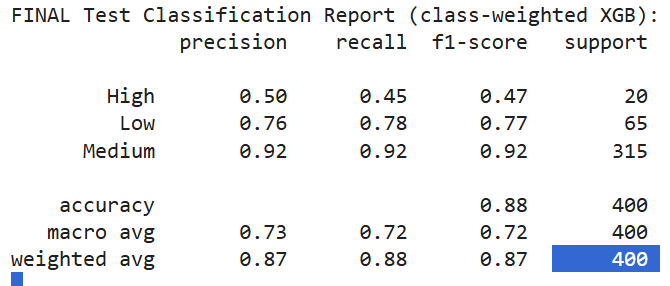

## Save the model as a .pkl file

In [38]:
import joblib

joblib.dump(model,'model_xgb_new.pkl')

print("Model saved successfully as 'model_xgb_new.pkl'")

Model saved successfully as 'model_xgb_new.pkl'
